# **XPM Identity Operator Analysis**

This notebook loads trained parameters from a run directory and generates analysis plots.

In [ ]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import yaml
import json

# ML imports
import torch
import torch.nn.functional as F

# Import module
from nlse import *

Using device: cpu


## **Setup: Load Run Directory**

In [4]:
# Specify the run directory to analyze
# You can change this to point to any run directory
run_dir = Path("res/16-mode")  # Change this to your run directory

print(f"Analyzing run directory: {run_dir}")

Analyzing run directory: res\16-mode


## **Load Configuration and Parameters**

In [5]:
# Load configuration
config_path = run_dir / "config.yaml"
with open(config_path, "r") as f:
    config = yaml.safe_load(f)

# Load losses
losses_path = run_dir / "losses.json"
with open(losses_path, "r") as f:
    losses = json.load(f)

# Load theta parameters
theta_path = run_dir / "parameters" / "theta.npy"
theta = torch.from_numpy(np.load(theta_path)).float()

print(f"Loaded theta with shape: {theta.shape}")
print(f"Configuration loaded from: {config_path}")
print(f"Losses loaded from: {losses_path}")

Loaded theta with shape: torch.Size([100])
Configuration loaded from: res\16-mode\config.yaml
Losses loaded from: res\16-mode\losses.json


## **Device Configuration**

In [6]:
# Device configuration for GPU support
device_config = config.get("device", {})
use_cuda = device_config.get("use_cuda", True) and torch.cuda.is_available()
if use_cuda:
    device_id = device_config.get("device_id", 0)
    device = torch.device(f"cuda:{device_id}")
    print(f"Using device: {device}")
    print(f"GPU: {torch.cuda.get_device_name(device_id)}")
    print(f"Memory Available: {torch.cuda.get_device_properties(device_id).total_memory / 1e9:.2f} GB")
else:
    device = torch.device("cpu")
    print(f"Using device: {device}")

# Move theta to device
theta = theta.to(device)

Using device: cpu


## **Reconstruct Simulation Setup**

In [7]:
# Extract parameters from config
sim = config["simulation"]
med = config["medium"]
pulse = config["pulse"]
train = config["training"]
plot = config["plotting"]

# Simulation parameters
Lz = float(sim["Lz"])
Nz = int(sim["Nz"])
Lt = float(sim["Lt"])
Nt = int(sim["Nt"])
N_modes = int(sim["N_modes"])

# Medium parameters
beta2_j = float(med["beta2_j"])
beta2_k = float(med["beta2_k"])
gamma_j = float(med["gamma_j"])
gamma_k = float(med["gamma_k"])

# Pulse parameters
tau = float(pulse["tau"])

# Training parameters
batch_size = int(train["batch_size"])
amplitude_downscale = float(train["amplitude_downscale"])

# Calculate derived parameters
dz = Lz / Nz
dt = Lt / Nt

# Create time grid
t = torch.linspace(-Lt/2, Lt/2, Nt, dtype=torch.float32, device=device)

# Define HG basis
hg_basis = get_hg_basis(N_modes, t, tau)

# Get batch of pulses (same as training)
B = batch_size
x = get_hg_basis(B, t, tau) * amplitude_downscale  # inputs
y = x.clone().detach()  # labels

print(f"Simulation setup reconstructed:")
print(f"  Lz={Lz}, Nz={Nz}, dz={dz}")
print(f"  Lt={Lt}, Nt={Nt}, dt={dt}")
print(f"  Batch size: {B}")
print(f"  HG modes: {N_modes}")

Precomputed 100 HG basis functions on grid of 2048 points on device cpu
Precomputed 16 HG basis functions on grid of 2048 points on device cpu
Simulation setup reconstructed:
  Lz=0.001, Nz=100, dz=1e-05
  Lt=10.0, Nt=2048, dt=0.0048828125
  Batch size: 16
  HG modes: 100


## **Forward Pass with Loaded Parameters**

In [8]:
# Define forward pass function (same as training)
def forward(theta, hg_basis):
    Ain_k = hg_to_time(theta, hg_basis)
    return split_step_fourier_xpm_batch(
        x, Ain_k, dz, Nz, 
        beta2_j, beta2_k, 
        gamma_j, gamma_k, 
        Lt
    )

# Run forward pass with loaded theta
print("Running forward pass with loaded theta...")
with torch.no_grad():
    A_j_evolution, A_k_evolution = forward(theta, hg_basis)

print(f"Forward pass completed!")
print(f"  A_j_evolution shape: {A_j_evolution.shape}")
print(f"  A_k_evolution shape: {A_k_evolution.shape}")

Running forward pass with loaded theta...
Forward pass completed!
  A_j_evolution shape: torch.Size([16, 2048, 101])
  A_k_evolution shape: torch.Size([16, 2048, 101])


## **Plotting Setup**

In [ ]:
# Plotting parameters
plot_percent = plot.get("plot_percent", 0.2)
modes_to_plot = plot.get("modes_to_plot", [0, 4, 15])

# Calculate the indices for the central portion
total_points = len(t)
center_points = int(total_points * plot_percent)
start_idx = (total_points - center_points) // 2
end_idx = start_idx + center_points
t_center = t[start_idx:end_idx].cpu().numpy()

print(f"Plotting parameters:")
print(f"  Plot percent: {plot_percent}")
print(f"  Modes to plot: {modes_to_plot}")

Plotting parameters:
  Plot percent: 0.2
  Mode number for evolution plots: 0
  Modes to plot: [0, 4, 15]


## **Plots**

### 1. Training Loss

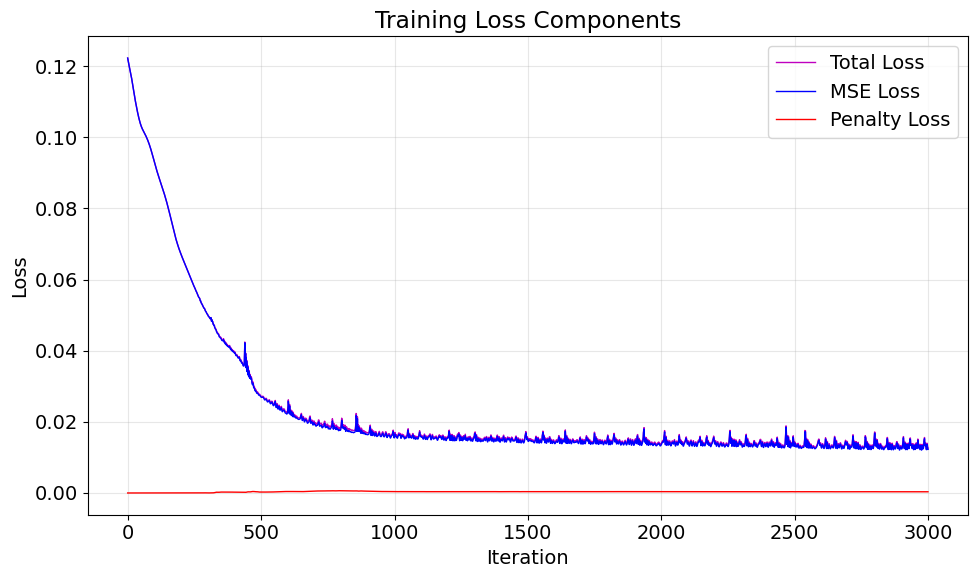

Final Loss: 0.012607
Final MSE Loss: 0.012270
Final Penalty Loss: 3.369594e-04


In [14]:
# Plot the loss
plt.figure(figsize=(10, 6))
plt.plot(losses["losses"], color="m", label="Total Loss", linewidth=1)
plt.plot(losses["losses_mse"], color="b", label="MSE Loss", linewidth=1)
plt.plot(losses["losses_pen"], color="r", label="Penalty Loss", linewidth=1)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss Components")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final Loss: {losses['final_loss']:.6f}")
print(f"Final MSE Loss: {losses['final_loss_mse']:.6f}")
print(f"Final Penalty Loss: {losses['final_loss_pen']:.6e}")

### Analzyzing specific mode

In [21]:
mode_nr = 15

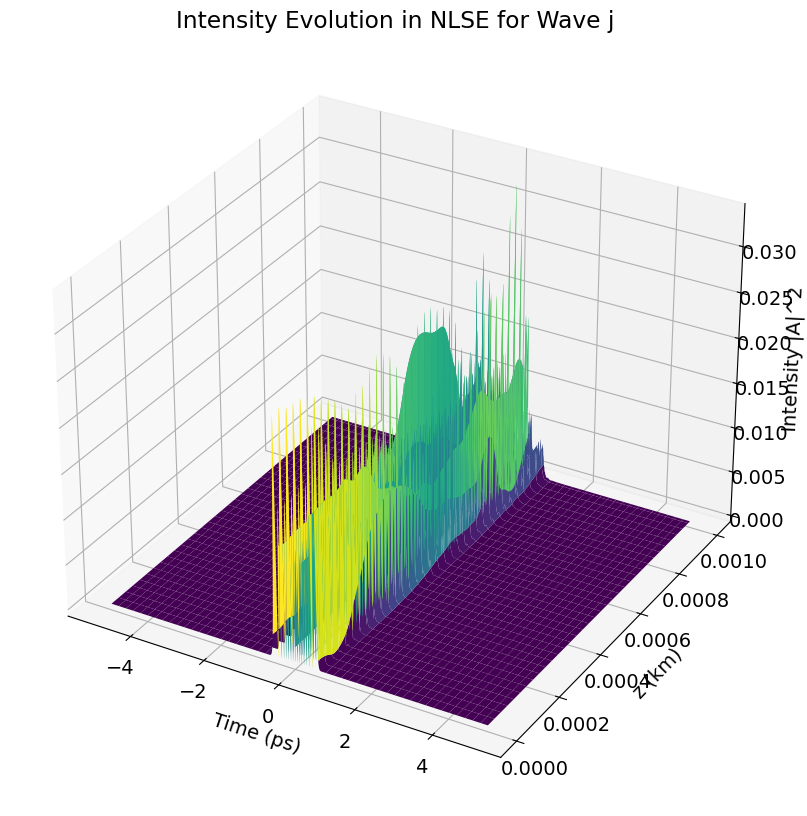

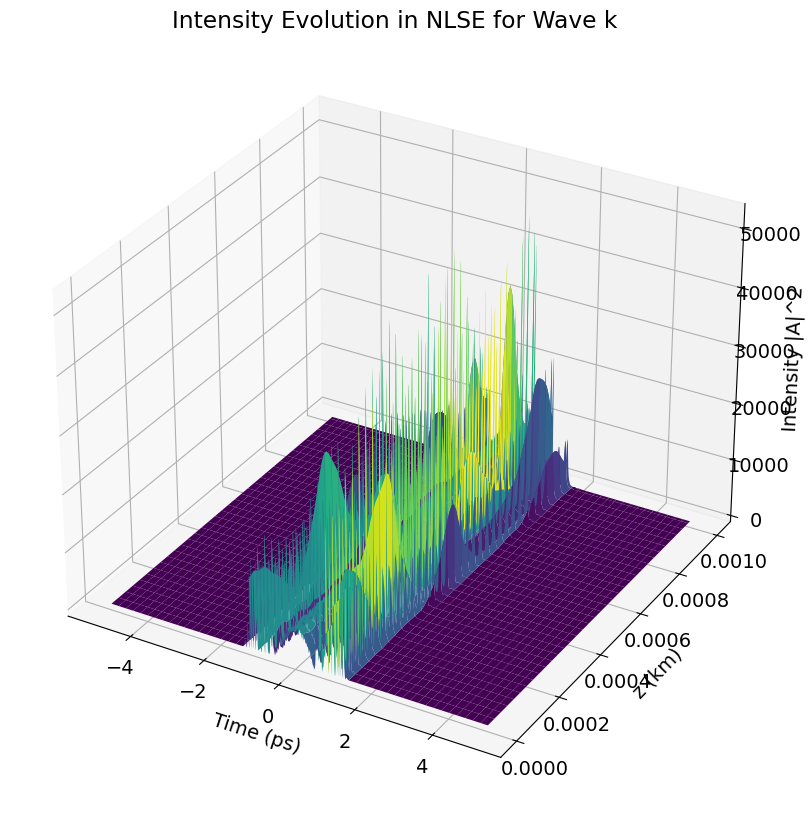

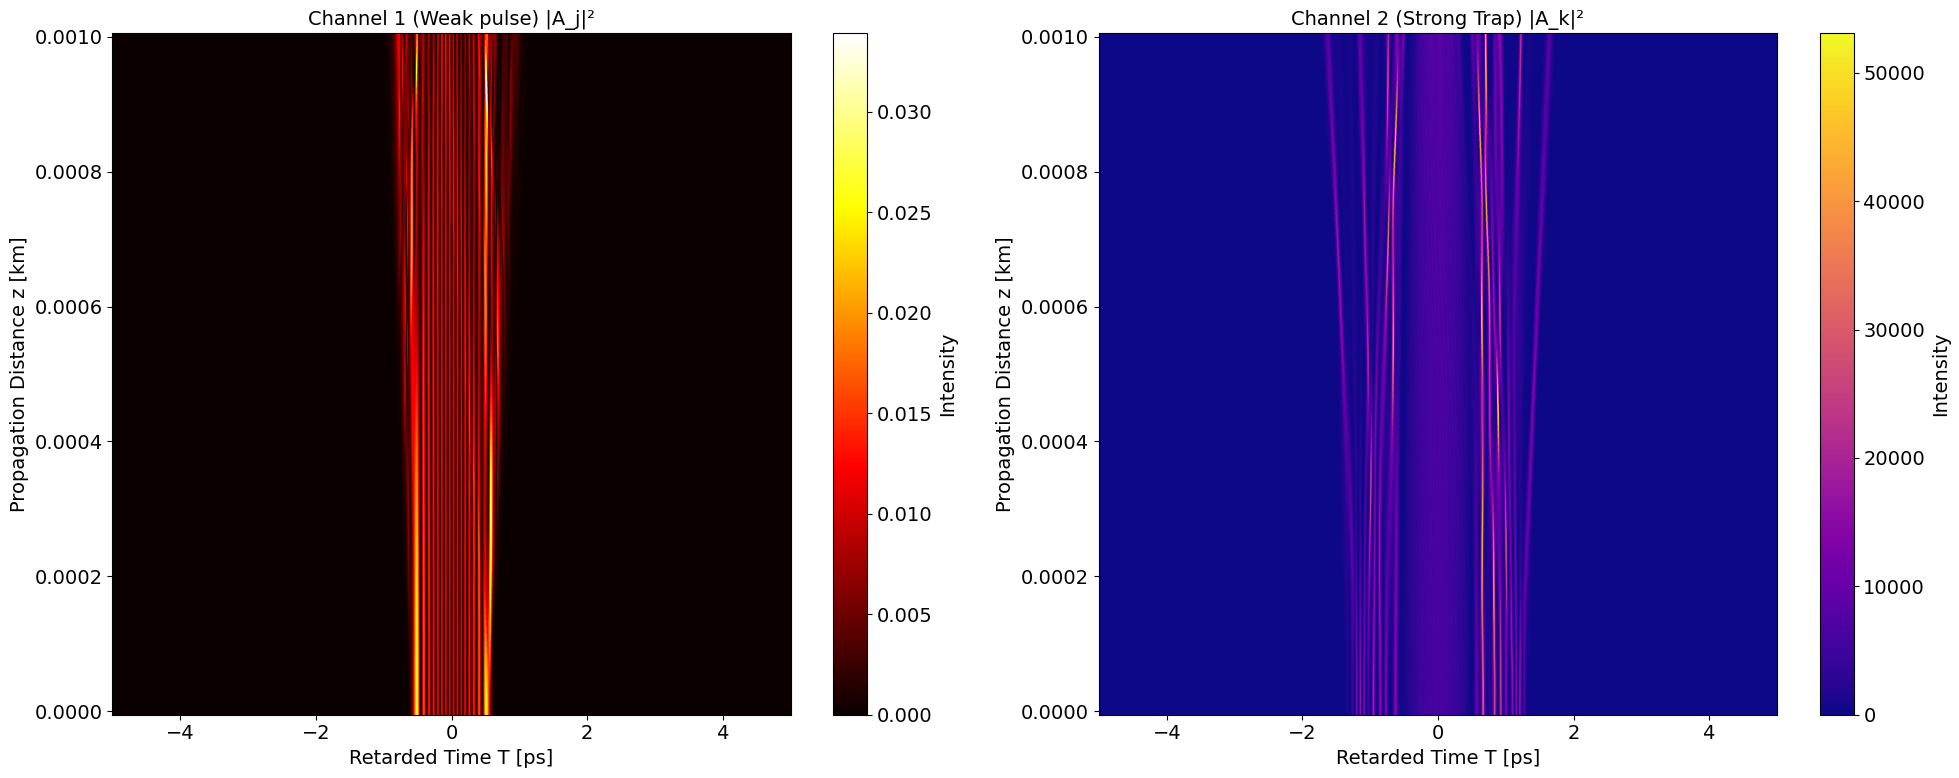

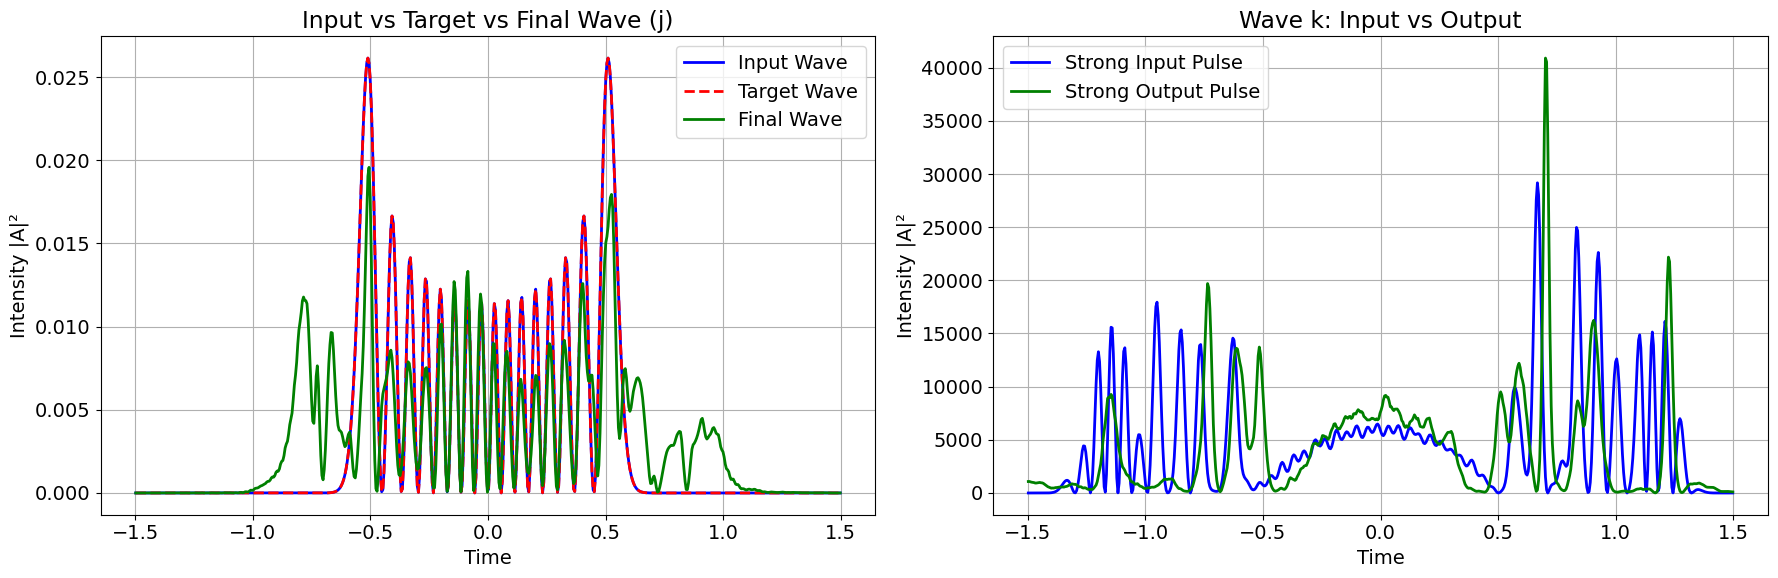

In [24]:
# Plot intensity evolution for wave j
plot_intensity_evolution(A_j_evolution[mode_nr, :, :], t, Lz, Nz, wave_name="Wave j")

# Plot intensity evolution for wave k
plot_intensity_evolution(A_k_evolution[mode_nr, :, :], t, Lz, Nz, wave_name="Wave k")

# Plot co-wave evolution
plot_cowave_evolution(
    A_j_evolution[mode_nr, :, :].detach().clone(),
    A_k_evolution[mode_nr, :, :].detach().clone(),
    t,
    Lz,
    Nz
)

"""------Target vs Final Wave------"""
# Plot target vs final wave comparison
plot_percent_comparison = 0.3  # Show central 30% of the data
center_points_comp = int(total_points * plot_percent_comparison)
start_idx_comp = (total_points - center_points_comp) // 2
end_idx_comp = start_idx_comp + center_points_comp
t_center_comp = t[start_idx_comp:end_idx_comp].cpu().numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# First subplot: Input vs Target vs Final wave (j)
ax1.plot(t_center_comp, np.abs(x[mode_nr].detach().cpu().numpy())[start_idx_comp:end_idx_comp]**2, 
        "b-", label="Input Wave", linewidth=2)
ax1.plot(t_center_comp, np.abs(y[mode_nr].detach().cpu().numpy())[start_idx_comp:end_idx_comp]**2, 
        "r--", label="Target Wave", linewidth=2)
ax1.plot(t_center_comp, np.abs(A_j_evolution[mode_nr, :, -1].detach().cpu().numpy())[start_idx_comp:end_idx_comp]**2, 
        "g-", label="Final Wave", linewidth=2)
ax1.set_xlabel("Time")
ax1.set_ylabel("Intensity |A|²")
ax1.set_title("Input vs Target vs Final Wave (j)")
ax1.legend()
ax1.grid()

# Second subplot: Wave k first and last
ax2.plot(t_center_comp, np.abs(A_k_evolution[mode_nr, :, 0].detach().cpu().numpy())[start_idx_comp:end_idx_comp]**2, 
        "b-", label="Strong Input Pulse", linewidth=2)
ax2.plot(t_center_comp, np.abs(A_k_evolution[mode_nr, :, -1].detach().cpu().numpy())[start_idx_comp:end_idx_comp]**2, 
        "g-", label="Strong Output Pulse", linewidth=2)
ax2.set_xlabel("Time")
ax2.set_ylabel("Intensity |A|²")
ax2.set_title("Wave k: Input vs Output")
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()

### 7. Loaded Theta Analysis (Optional)

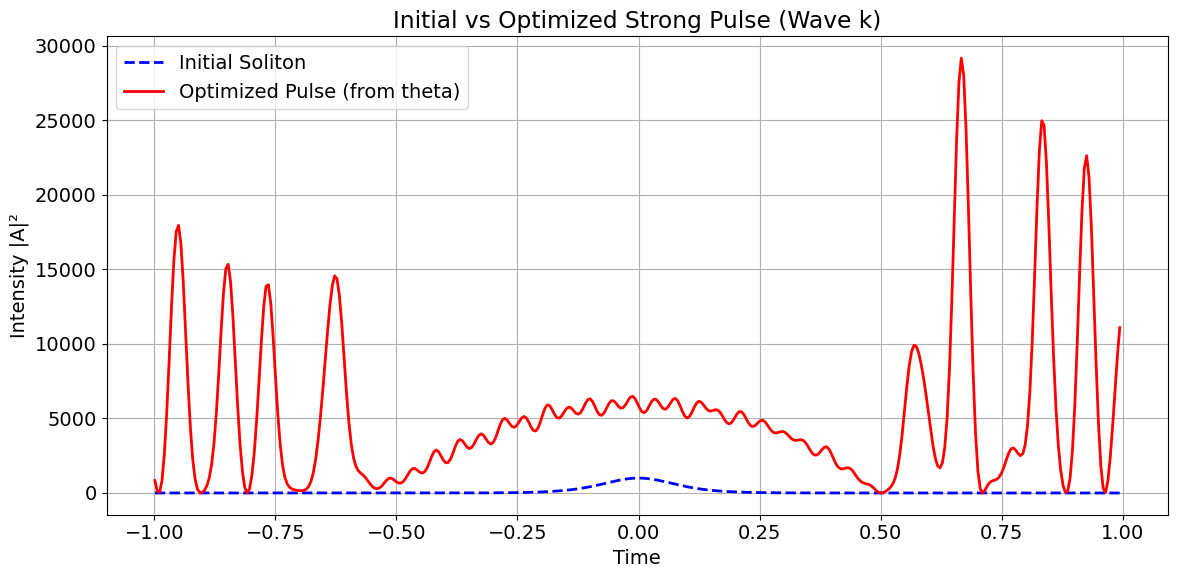

Theta statistics:
  Mean: 0.741226
  Std: 11.921607
  Min: -28.470657
  Max: 45.072662


In [20]:
# Convert theta back to time domain to visualize the strong pulse
Ain_k_loaded = hg_to_time(theta, hg_basis)

# Compare with initial soliton
def strong_soliton(t, beta2_k, gamma_k, tau):
    """Create the strong pulse (A_k) based on the soliton parameters."""
    a_2_squared = -beta2_k / (gamma_k * tau**2)
    a_2 = np.sqrt(a_2_squared)
    Ain_k = a_2 * torch.cosh(t / tau)**(-1)
    return Ain_k

A_strong_initial = strong_soliton(t, beta2_k, gamma_k, tau)

# Plot comparison
plt.figure(figsize=(12, 6))
plt.plot(t_center, np.abs(A_strong_initial[start_idx:end_idx].cpu().numpy())**2, 
        "b--", label="Initial Soliton", linewidth=2)
plt.plot(t_center, np.abs(Ain_k_loaded[start_idx:end_idx].detach().cpu().numpy())**2, 
        "r-", label="Optimized Pulse (from theta)", linewidth=2)
plt.xlabel("Time")
plt.ylabel("Intensity |A|²")
plt.title("Initial vs Optimized Strong Pulse (Wave k)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Theta statistics:")
print(f"  Mean: {theta.mean().item():.6f}")
print(f"  Std: {theta.std().item():.6f}")
print(f"  Min: {theta.min().item():.6f}")
print(f"  Max: {theta.max().item():.6f}")

### 8. Mode Comparison Plot (All 16 Modes)


In [ ]:
def plot_mode_comparison(y, t, A_j_evolution, plot_percent=0.3):
    """Create a 4x4 grid plot showing all 16 modes: target vs final output."""
    B = y.shape[0]
    
    # Calculate time window for plotting
    total_points = len(t)
    center_points = int(total_points * plot_percent)
    start_idx = (total_points - center_points) // 2
    end_idx = start_idx + center_points
    t_plot = t[start_idx:end_idx].cpu().numpy()
    
    # Get final outputs
    final_outputs = A_j_evolution[:, :, -1].detach()
    
    # Create 4x4 subplot grid
    fig, axes = plt.subplots(4, 4, figsize=(16, 16))
    axes = axes.flatten()
    
    for mode_idx in range(B):
        ax = axes[mode_idx]
        
        # Extract data for this mode
        target_intensity = np.abs(y[mode_idx].detach().cpu().numpy())[start_idx:end_idx]**2
        output_intensity = np.abs(final_outputs[mode_idx].detach().cpu().numpy())[start_idx:end_idx]**2
        
        # Plot target and output
        ax.plot(t_plot, target_intensity, 'r--', linewidth=2, label='Target', alpha=0.7)
        ax.plot(t_plot, output_intensity, 'b-', linewidth=2, label='Output', alpha=0.8)
        
        # Calculate and display MSE
        mse = np.mean((target_intensity - output_intensity)**2)
        ax.set_title(f'Mode {mode_idx}\nMSE: {mse:.2e}', fontsize=10)
        ax.set_xlabel('Time', fontsize=9)
        ax.set_ylabel('Intensity |A|²', fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('Target vs Final Output for All 16 Modes', fontsize=16, y=0.995)
    plt.tight_layout()
    plt.show()


In [ ]:
# Generate mode comparison plot
plot_mode_comparison(y, t, A_j_evolution, plot_percent=0.3)

# Print summary statistics
final_outputs = A_j_evolution[:, :, -1].detach()
targets = y
mse_per_mode = torch.mean((torch.abs(final_outputs)**2 - torch.abs(targets)**2)**2, dim=1)
print(f"\nSummary Statistics:")
print(f"  Mean MSE per mode: {mse_per_mode.mean().item():.2e}")
print(f"  Std MSE per mode: {mse_per_mode.std().item():.2e}")
print(f"  Min MSE: {mse_per_mode.min().item():.2e}")
print(f"  Max MSE: {mse_per_mode.max().item():.2e}")
